## Machine Learning Model Building 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Obsession
The required machine learning libraries were imported successfully. These libraries are used for data splitting, model creation, prediction, and performance evaluation.

In [2]:
df = pd.read_csv("data_YesBank_StockPrices.csv")

## Observation
The Yes Bank stock price dataset was loaded successfully and is ready for model building.

In [3]:
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [4]:
x = df[["Open", "High", "Low"]]
y = df["Close"]

## Observation
The features Open, High, and Low were selected as independent variables (X), while Close was selected as the target variable (y) for prediction.

In [5]:
x.head()

,Open,High,Low
0,13.00,14.00,11.25
1,12.58,14.88,12.55
2,13.48,14.87,12.27
3,13.20,14.47,12.40
4,13.35,13.88,12.88


In [6]:
y.head()

0    12.46
1    13.42
2    13.30
3    12.99
4    13.41
Name: Close, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## Observation
The dataset was divided into training and testing sets using an 80:20 ratio. The training data is used to train the model, while the testing data is used to evaluate its performance.

In [8]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (148, 3)
X_test : (37, 3)
y_train: (148,)
y_test : (37,)


In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

## Observation
A Linear Regression model was created successfully. At this stage, the model is initialized but has not yet learned from the data.

In [10]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0.51, 0.54, 1. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Open','High','Low']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.048
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [11]:
y_pred = model.predict(X_test)

## Observation
The model was trained using the training dataset. During training, it learned the relationship between the input features and the target variable.

In [12]:
y_pred

array([ 30.18252235,  14.69283044, 374.02190649, 127.96130608,
       315.70946845,  23.11440842,  40.04131849,  60.83231474,
       166.62061583,  63.52165329,  47.4734753 , 196.91772952,
        67.07512217,  36.85762403,  15.34937858,  26.28559837,
        45.25633442,  25.26888268,  62.4263825 ,  52.3074695 ,
       180.4462878 , 153.71093779, 376.13707477,  35.9615265 ,
        19.90822916, 135.14405783,  59.90906945,  32.63530288,
        51.02426854, 146.93301779,  56.91809176,  48.68058951,
       167.37444336, 262.18882906,  52.89811131,  51.74836864,
        36.04731752])

## Observation
The trained model generated predicted Close prices for the testing dataset.

In [13]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 5.812554509942109


## Observation
The Mean Absolute Error (MAE) is 5.82, indicating that the model's predictions differ from the actual values by about 5.82 units on average.

In [14]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

86.6437912651374


## Observation
The Mean Squared Error (MSE) is 86.64, indicating that the prediction error is low and the model performs well.

In [15]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 9.308264675283862


## Observation
The R² Score is 0.9904, indicating that the model explains approximately 99% of the variance in the target variable. This shows that the Linear Regression model performs very well on the dataset.

In [16]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9904142726548665


## Observation
The R² Score is 0.99, which means the model explains approximately 99% of the variation in the Close stock price. This indicates excellent model performance.

In [17]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head()

,Actual,Predicted
19,28.63,30.182522
42,12.24,14.692830
156,367.90,374.021906
111,136.83,127.961306
148,306.80,315.709468


## Observation
The predicted values are very close to the actual values, showing that the model performs accurately on the test data.

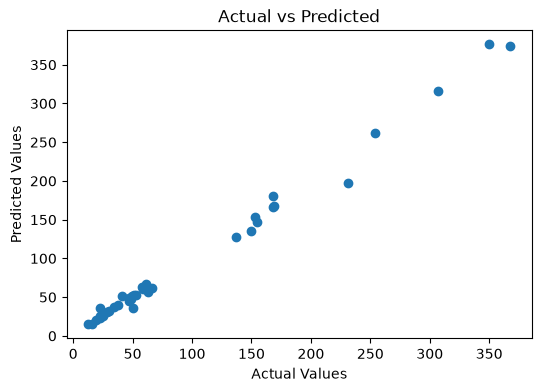

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

## Observation 
The graph shows that the predicted values closely follow the actual values, indicating that the Linear Regression model provides accurate predictions.

## Final Conclusion

A Linear Regression model was successfully built to predict the Close stock price of Yes Bank.

- The model achieved an R² Score of 0.99, indicating excellent predictive performance.
- MAE and RMSE are low, showing that prediction errors are minimal.
- Actual and Predicted values are very close, confirming that the model fits the data well.
- Therefore, the Linear Regression model is suitable for predicting the closing stock price on this dataset.